In [1]:
%load_ext autoreload
%autoreload 2
import sys; sys.path.append("..")
from src.data import load_raw, get_splits

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import average_precision_score, roc_auc_score, classification_report

df = load_raw()
X_tr, X_te, y_tr, y_te = get_splits()

baseline = Pipeline([
    ("scale",StandardScaler()),
    ("lr",LogisticRegression(max_iter = 100, class_weight = "balanced")),
]).fit(X_tr, y_tr)

p = baseline.predict_proba(X_te)[:, 1]
print(f"PR_AUC : {average_precision_score(y_te, p):.4f}")
print(f"ROC_AUC : {roc_auc_score(y_te, p):.4f}")
print(classification_report(y_te, (p >= 0.5).astype(int), digits = 4))

PR_AUC : 0.7289
ROC_AUC : 0.9721
              precision    recall  f1-score   support

           0     0.9999    0.9756    0.9876     56864
           1     0.0610    0.9184    0.1144        98

    accuracy                         0.9755     56962
   macro avg     0.5304    0.9470    0.5510     56962
weighted avg     0.9982    0.9755    0.9861     56962



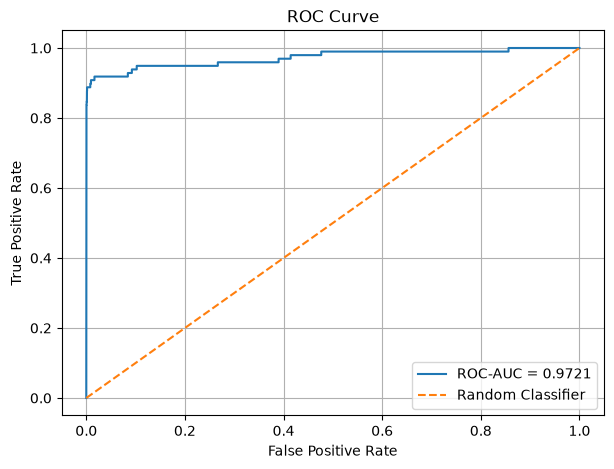

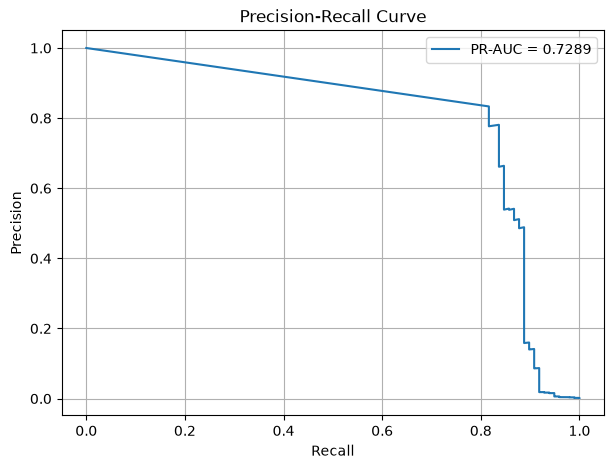

In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve

# -------------------------
# ROC Curve
# -------------------------
fpr, tpr, thresholds = roc_curve(y_te, p)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc_score(y_te, p):.4f}")
plt.plot([0, 1], [0, 1], "--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()


# -------------------------
# Precision-Recall Curve
# -------------------------
precision, recall, thresholds = precision_recall_curve(y_te, p)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision,
         label=f"PR-AUC = {average_precision_score(y_te, p):.4f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid()
plt.show()

# Confusion Matrix, ROC & PR Curves

## 1. Confusion Matrix

|                        | Actual Positive                       | Actual Negative                       |
| ---------------------- | ------------------------------------- | ------------------------------------- |
| **Predicted Positive** | **TP** – Correctly predicted positive | **FP** – False alarm                  |
| **Predicted Negative** | **FN** – Missed positive              | **TN** – Correctly predicted negative |

### Key Metrics

* **Accuracy** = `(TP + TN) / Total` → Overall correctness
* **Precision** = `TP / (TP + FP)` → Of predicted positives, how many are actually positive?
* **Recall (TPR)** = `TP / (TP + FN)` → Of actual positives, how many did we catch?
* **Specificity (TNR)** = `TN / (TN + FP)` → Of actual negatives, how many did we correctly identify?
* **FPR** = `FP / (FP + TN)` → Of actual negatives, how many did we incorrectly flag?
* **F1 Score** = `2 × (Precision × Recall) / (Precision + Recall)` → Balance between precision and recall

---

## 2. Why ROC and PR Curves?

A classification model gives a **probability**, e.g. `0.82`.

We choose a **threshold**:

```text
Probability ≥ threshold → Positive
Probability < threshold → Negative
```

Changing the threshold changes TP, FP, FN and TN, which changes our metrics.

### ROC Curve

* **X-axis:** FPR
* **Y-axis:** TPR / Recall
* Shows the trade-off between **catching positives** and **false alarms**.
* Higher and closer to the **top-left** is better.

### Precision-Recall Curve

* **X-axis:** Recall
* **Y-axis:** Precision
* Shows the trade-off between **finding more positives** and **keeping predictions trustworthy**.
* Particularly useful for **imbalanced datasets** such as fraud detection.

---

## 3. Why does your PR curve drop?

As we **lower the threshold**:

```text
Lower threshold
      ↓
More positives predicted
      ↓
Recall ↑
      ↓
More False Positives
      ↓
Precision ↓
```

In your graph, precision stays relatively high until around **80% recall**. After that, it drops sharply.

This means:

> The model can catch roughly 80% of fraud cases while maintaining reasonable precision. To catch the remaining difficult cases, it starts generating many more false positives.

Your **PR-AUC = 0.7289** summarizes the overall Precision-Recall performance.

---

## 4. ROC vs PR — Quick Difference

| ROC                                      | PR                                       |
| ---------------------------------------- | ---------------------------------------- |
| TPR vs FPR                               | Precision vs Recall                      |
| Focuses on class separation              | Focuses on positive predictions          |
| Can look optimistic with heavy imbalance | More informative for imbalanced problems |
| Useful overall view                      | Especially useful for fraud detection    |


In [7]:
import os; print(os.getcwd())

c:\Users\Legion\fraud-detection-mlops


In [ ]:
# Logging the baseline
from src.tracking import init,log_run
init()

p = log_run("baseline_logreg", baseline, X_tr, y_tr, X_te, y_te,
            params={"model":"logreg","class_weight":"balanced"})

2026/08/13 21:03:37 INFO mlflow.tracking.fluent: Experiment with name 'fraud-p1' does not exist. Creating a new experiment.


In [17]:
# Verify from python
import mlflow
runs = mlflow.search_runs(experiment_names = ["fraud-p1"])
runs[["run_id","metrics.pr_auc","metrics.roc_auc","params.model","status"]]

,run_id,metrics.pr_auc,metrics.roc_auc,params.model,status
0,61ae5fc90d054789a4b0fbbcf9afaa3d,0.728925,0.972088,logreg,FINISHED


In [ ]:
# fast tracked comaprison
from src.tracking import init,log_run
from xgboost import XGBClassifier
init()

spw = (y_tr == 0).sum()/(y_tr == 1).sum()


log_run("xgb_scale",
        XGBClassifier(n_estimators = 400, max_depth = 4, learning_rate =0.1,
                      eval_metric="aucpr", random_state = 42),
        X_tr, y_tr, X_te, y_te)

log_run("xgb_scale_pos_weight",
        XGBClassifier(n_estimators = 400, max_depth = 4, learning_rate =0.1,
                      scale_pos_weight = spw, eval_metric="aucpr", random_state = 42),
        X_tr, y_tr, X_te, y_te, {"scale_pos_weight":round(float(spw), 1)})

array([8.2771903e-06, 4.0119841e-07, 6.2917147e-06, ..., 5.2225874e-07,
       1.5196677e-05, 6.7637518e-07], shape=(56962,), dtype=float32)

In [30]:
#plotting PR + ROC for three model
from src.tracking import init,log_run
init()

In [11]:
#importing mlflow
import mlflow
exp = mlflow.get_experiment_by_name("fraud-p1")

runs = mlflow.search_runs(experiment_ids = [exp.experiment_id])

models = mlflow.search_logged_models(experiment_ids = [exp.experiment_id], output_format = "list")

probs= {}
for m in models:
    print(m.name, m.model_id, m.status) #checking if logged model have failed
    if m.status != "READY":
        continue
    name = runs.loc[runs.run_id == m.source_run_id, "tags.mlflow.runName"].iloc(0)
    probs[name] = mlflow.pyfunc.load_model(f"models:/{m.model_id}").predict(X_te)

print(list(probs))

model m-095321b6ac8c4b2baf8c035bd24bf2d1 READY
model m-f116412f7b4646f9947ce10df804f96d READY
model m-68b617e57ad54a61bbc2090801d876df FAILED
model m-cffa64ec92e549deb9f07fbd196b46fa FAILED
model m-dfa71609d10f4026bd961cc68f6a890a READY
[<pandas.core.indexing._iLocIndexer object at 0x0000022A472FAD00>, <pandas.core.indexing._iLocIndexer object at 0x0000022A41CC4730>, <pandas.core.indexing._iLocIndexer object at 0x0000022A47EA6760>]


In [12]:
from mlflow import MlflowClient
c = MlflowClient()

bad = runs[runs.status == "FAILED"].run_id.tolist()
for rid in bad:
    c.delete_run(rid)
print("deleted", len(bad))

deleted 0


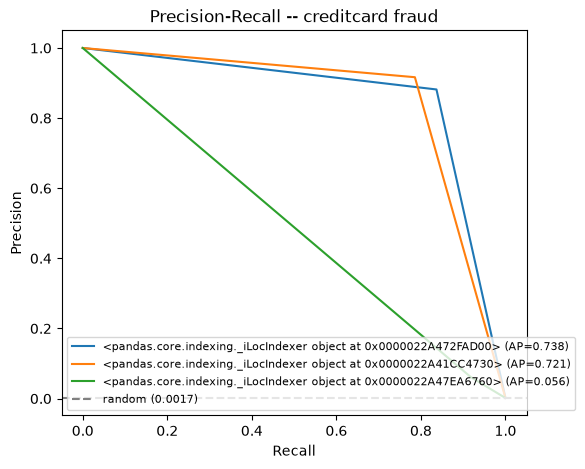

In [13]:
# plotting the model on single axes
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

fig, ax = plt.subplots(figsize=(6,5))

for name, p in probs.items():
    prec, rec, _ = precision_recall_curve(y_te, p)
    ap = average_precision_score(y_te, p)
    ax.plot(rec, prec, label=f"{name} (AP={ap:.3f})")

ax.axhline(y_te.mean(), ls="--", c="grey", label=f"random ({y_te.mean():.4f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall -- creditcard fraud")
ax.legend(loc="lower left", fontsize=8)
fig.savefig("reports/figures/04_pr_curves.png", dpi=150, bbox_inches="tight")

In [19]:
### Adding Random Forest run
from src.tracking import log_run, init
from sklearn.ensemble import RandomForestClassifier
init()

log_run("random_forest",
        RandomForestClassifier(n_estimators = 200, class_weight = "balanced",
                      n_jobs=-1, random_state = 42),
        X_tr, y_tr, X_te, y_te)



array([0.  , 0.  , 0.01, ..., 0.  , 0.  , 0.  ], shape=(56962,))

In [ ]:
### Logging LightGBM
from src.tracking import init,log_run
from lightgbm import LGBMClassifier
init()

log_run("LightBGM",
        LGBMClassifier(n_estimators = 200, learning_rate= 0.05, class_weight = "balanced",
                       n_jobs = -1, random_state = 42),
                       X_tr, y_tr, X_te, y_te)



[LightGBM] [Info] Number of positive: 394, number of negative: 227451
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.018322 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 227845, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


array([9.36469715e-05, 5.79428525e-05, 4.90482466e-04, ...,
       3.51575719e-05, 1.03966587e-04, 5.52352904e-05], shape=(56962,))

In [22]:
# trying lightGBM with scale_pos
spw = (y_tr == 0).sum()/(y_tr == 1).sum()
log_run("LightBGM_scale_pos_weight",
        LGBMClassifier(n_estimators = 200, learning_rate= 0.05, scale_pos_weight = spw,
                       n_jobs = -1, random_state = 42),
                       X_tr, y_tr, X_te, y_te)

[LightGBM] [Info] Number of positive: 394, number of negative: 227451
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.021697 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 227845, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.001729 -> initscore=-6.358339
[LightGBM] [Info] Start training from score -6.358339


array([0.00732069, 0.        , 0.        , ..., 0.00015819, 0.        ,
       0.        ], shape=(56962,))

### Precision/ Recall
Recall is how well you are correcting predicitng the positive exampples so predicted positve by total actual posiitve (keep 1 for all you get 100% recall). /n In case of precision you rather see how precise your model is so out of total positive prediction how many are actual positive. Given precision tells us out of how precise we are in terms of our correct prediction where as recall just tells us if we get all correct prediction in the model.



We are using Optuna library which is a hyperparameter tuning library so rather than making each combination of parameter we give a range of each paramter and then the optuna helps in training the model using all possible and best hyperparameters. Stratified fold on the other hand helps us to break the dataset into K fold where the split of positive and negative example as in same ratio as original data.